<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/TimeA011.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

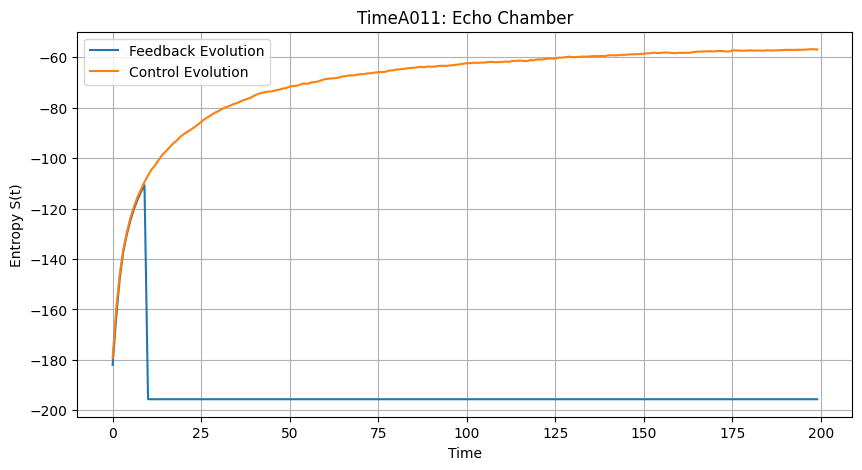

Feedback Evolution Metrics:
Entropy Slope: -0.08598
Memory Retention: 0.89990
Irreversibility Index: 156.23738
Resonance Amplitude: 0.45435

Control Evolution Metrics:
Entropy Slope: 0.24248
Memory Retention: 0.99831
Irreversibility Index: 129.80659
Resonance Amplitude: 0.43546


In [2]:
# 🔁 TimeA011: The Echo Chamber
# Testing temporal feedback and resonance in HES lattice
# Author: Chris & Copilot | Arc V: Entropic Ascent | ACT035
# Reproducibility Tag: TimeA011_v1

import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
N = 100  # lattice size
T = 200  # timesteps
feedback_strength = 0.1
bias_strength = 0.05
xi_locking = True
seed = 42
np.random.seed(seed)

# --- Curvature Profile: Exponential ---
def exponential_curvature(N):
    x = np.linspace(-1, 1, N)
    return -np.exp(-5 * x**2)[:, None]

# --- Initialization ---
def initialize_lattice(N):
    base = np.random.rand(N, N)
    curvature = exponential_curvature(N)
    return base + curvature

# --- Entropy Calculation ---
def compute_entropy(lattice):
    hist, _ = np.histogram(lattice, bins=50, density=True)
    hist = hist[hist > 0]
    return -np.sum(hist * np.log(hist))

# --- Evolution Functions ---
def evolve_with_feedback(lattice, xi_locking, bias_strength, feedback_strength, past_entropy):
    entropy_map = np.gradient(lattice)[0]
    feedback_scalar = feedback_strength * (np.mean(past_entropy) if len(past_entropy) > 0 else 0)
    feedback_field = np.full_like(lattice, feedback_scalar)
    lattice += 0.01 * np.random.randn(*lattice.shape) + bias_strength * entropy_map + feedback_field
    if xi_locking:
        lattice = np.clip(lattice, 0.2, 0.8)
    return lattice

def evolve_control(lattice, xi_locking, bias_strength):
    entropy_map = np.gradient(lattice)[0]
    lattice += 0.01 * np.random.randn(*lattice.shape) + bias_strength * entropy_map
    if xi_locking:
        lattice = np.clip(lattice, 0.2, 0.8)
    return lattice

# --- Simulation Loop ---
def run_simulation(N, T, feedback=False):
    lattice = initialize_lattice(N)
    entropy_series = []
    cumulative_drift = np.zeros_like(lattice)
    for t in range(T):
        prev_lattice = lattice.copy()
        past_entropy = np.array(entropy_series[-10:]) if len(entropy_series) >= 10 else np.zeros(10)
        if feedback:
            lattice = evolve_with_feedback(lattice, xi_locking, bias_strength, feedback_strength, past_entropy)
        else:
            lattice = evolve_control(lattice, xi_locking, bias_strength)
        cumulative_drift += lattice - prev_lattice
        S = compute_entropy(lattice)
        entropy_series.append(S)
    return np.array(entropy_series), cumulative_drift

# --- Metrics ---
def compute_metrics(entropy_series, cumulative_drift):
    slope = np.polyfit(np.arange(len(entropy_series)), entropy_series, 1)[0]
    memory = np.corrcoef(entropy_series[:-1], entropy_series[1:])[0,1]
    irreversibility_index = np.sum(np.abs(np.diff(entropy_series)))
    resonance_amplitude = np.std(cumulative_drift)
    return slope, memory, irreversibility_index, resonance_amplitude

# --- Run Feedback and Control ---
feedback_entropy, feedback_drift = run_simulation(N, T, feedback=True)
control_entropy, control_drift = run_simulation(N, T, feedback=False)

feedback_metrics = compute_metrics(feedback_entropy, feedback_drift)
control_metrics = compute_metrics(control_entropy, control_drift)

# --- Plotting ---
plt.figure(figsize=(10,5))
plt.plot(feedback_entropy, label='Feedback Evolution')
plt.plot(control_entropy, label='Control Evolution')
plt.xlabel('Time')
plt.ylabel('Entropy S(t)')
plt.title('TimeA011: Echo Chamber')
plt.legend()
plt.grid(True)
plt.show()

# --- Output ---
print("Feedback Evolution Metrics:")
print(f"Entropy Slope: {feedback_metrics[0]:.5f}")
print(f"Memory Retention: {feedback_metrics[1]:.5f}")
print(f"Irreversibility Index: {feedback_metrics[2]:.5f}")
print(f"Resonance Amplitude: {feedback_metrics[3]:.5f}")

print("\nControl Evolution Metrics:")
print(f"Entropy Slope: {control_metrics[0]:.5f}")
print(f"Memory Retention: {control_metrics[1]:.5f}")
print(f"Irreversibility Index: {control_metrics[2]:.5f}")
print(f"Resonance Amplitude: {control_metrics[3]:.5f}")
